In [11]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
from math import sqrt
from keras.models import Sequential
from keras.layers import Dense, LSTM


In [12]:
# Downloading stock data from Yahoo Finance
yf.pdr_override()  # Overriding pandas datareader with yfinance

# Get the stock quote for Hindustan Unilever Limited (HUL)
start_date = '2004-01-01'
end_date = '2024-03-03'

# Retrieving stock data from Yahoo Finance
df = yf.download('HINDUNILVR.NS', start=start_date, end=end_date)

df.head()


[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-01-01,205.899994,215.500000,205.899994,212.750000,135.129913,5400168
2004-01-02,215.500000,216.699997,212.100006,215.449997,136.844788,2859177
2004-01-05,217.699997,218.000000,211.000000,214.399994,136.177887,2075535
2004-01-06,214.300003,218.000000,212.000000,213.649994,135.701508,2971776
2004-01-07,213.699997,213.699997,206.000000,209.949997,133.351456,2037340


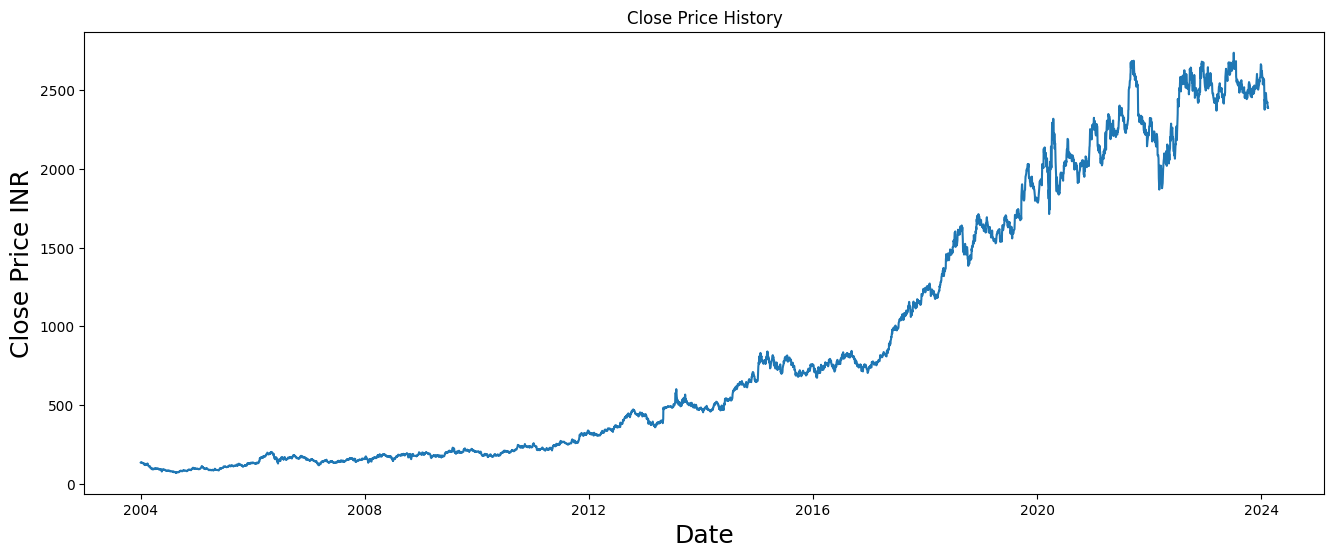

In [13]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Adj Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR', fontsize=18)
plt.show()

In [14]:
# Create a new dataframe with only the 'Close column 
data = df.filter(['Adj Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len
# Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)


# Create the training data set 
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape


# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002 
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse


[array([0.02426678, 0.02490987, 0.02465978, 0.02448113, 0.02359984,
       0.02371891, 0.02407619, 0.02307582, 0.02333783, 0.02295672,
       0.02312346, 0.02257563, 0.02273044, 0.0221826 , 0.02131322,
       0.01964589, 0.02008653, 0.02008653, 0.02157521, 0.01959825,
       0.01834775, 0.01834775, 0.01834775, 0.01889559, 0.01961016,
       0.01971734, 0.01872885, 0.01956251, 0.0199079 , 0.02015799,
       0.02055101, 0.02196823, 0.02113456, 0.01951488, 0.01831203,
       0.01700198, 0.01625167, 0.01516793, 0.01544183, 0.01517983,
       0.01481064, 0.01502501, 0.01503691, 0.01503691, 0.01290511,
       0.01126161, 0.01133306, 0.01091624, 0.01045175, 0.00926081,
       0.01040412, 0.01085668, 0.01026121, 0.00939183, 0.00790314,
       0.00816513, 0.00889162, 0.00927273, 0.00951092, 0.00889162])]
[0.007998397195680677]

[array([0.02426678, 0.02490987, 0.02465978, 0.02448113, 0.02359984,
       0.02371891, 0.02407619, 0.02307582, 0.02333783, 0.02295672,
       0.02312346, 0.02257563, 0.0

47.601601350269426

/var/folders/5_/dt8hhmsn2wbd_9pqy9vv5x4c0000gn/T/ipykernel_9252/2848346960.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


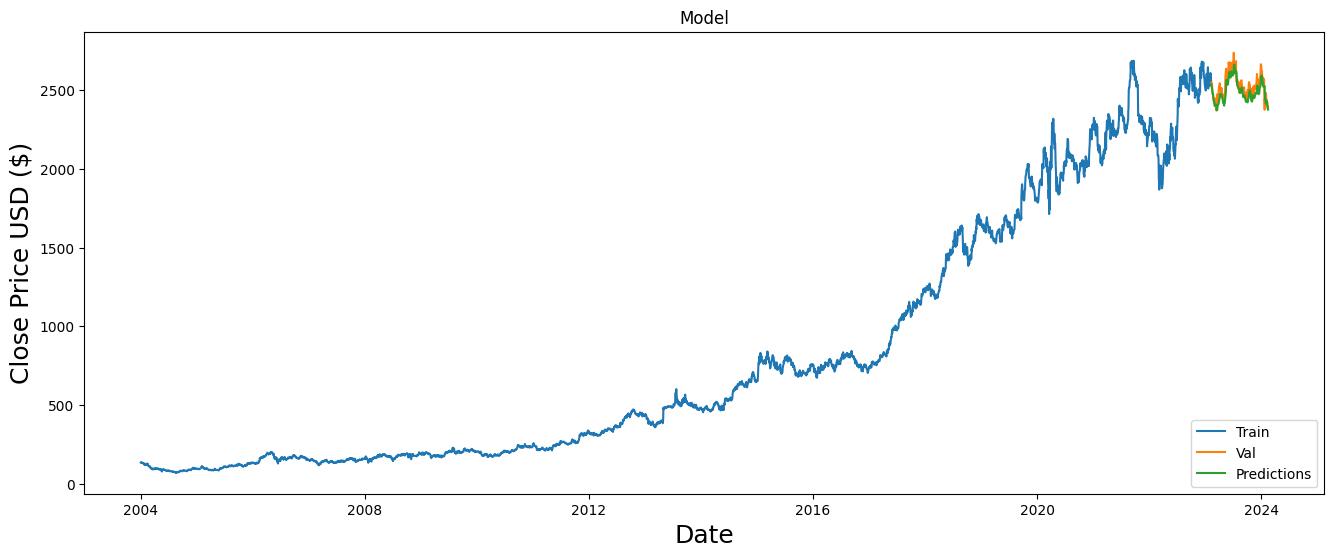

In [15]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Adj Close'])
plt.plot(valid[['Adj Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [16]:
valid

,Adj Close,Predictions
Date,,
2023-02-09,2547.063965,2535.373779
2023-02-10,2538.004883,2525.321289
2023-02-13,2541.451172,2515.358154
2023-02-14,2540.072998,2508.885254
2023-02-15,2509.399902,2505.134521
...,...,...
2024-02-08,2417.050049,2406.773193
2024-02-09,2424.149902,2398.818115
2024-02-12,2385.649902,2394.744141


[*********************100%%**********************]  1 of 1 completed


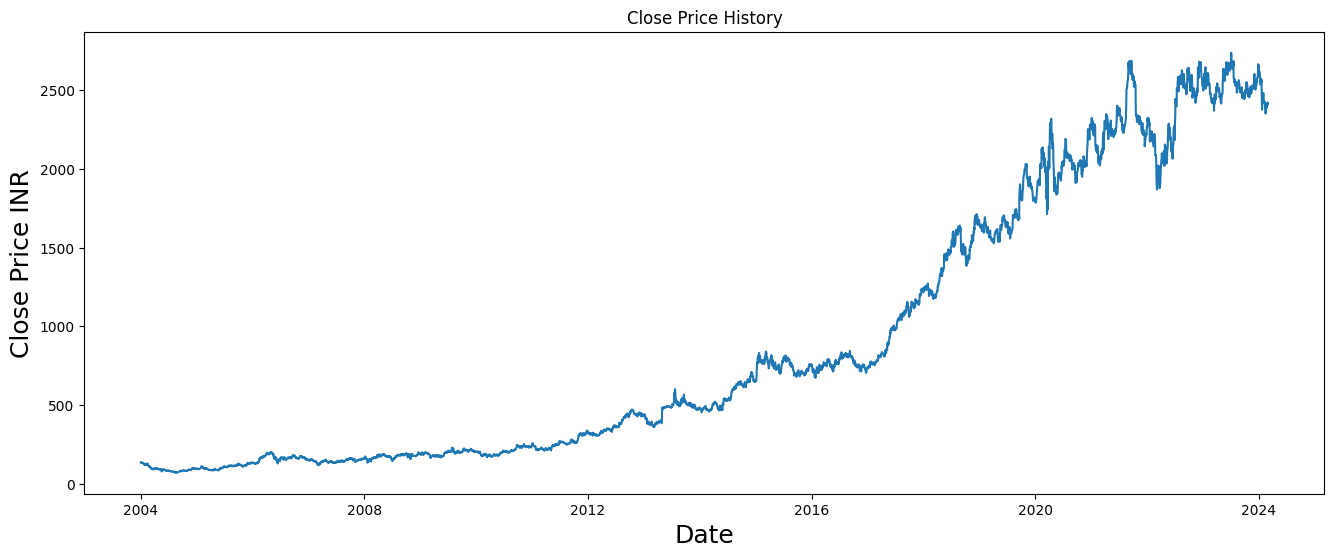

8/8 [==============================] - 0s 12ms/step
Root Mean Squared Error: 181.4324590534166
1/1 [==============================] - 0s 10ms/step


/var/folders/5_/dt8hhmsn2wbd_9pqy9vv5x4c0000gn/T/ipykernel_9252/3601690088.py:109: FutureWarning: Argument `closed` is deprecated in favor of `inclusive`.
  index = pd.date_range(start=df.index[-1], periods=31, closed='right')


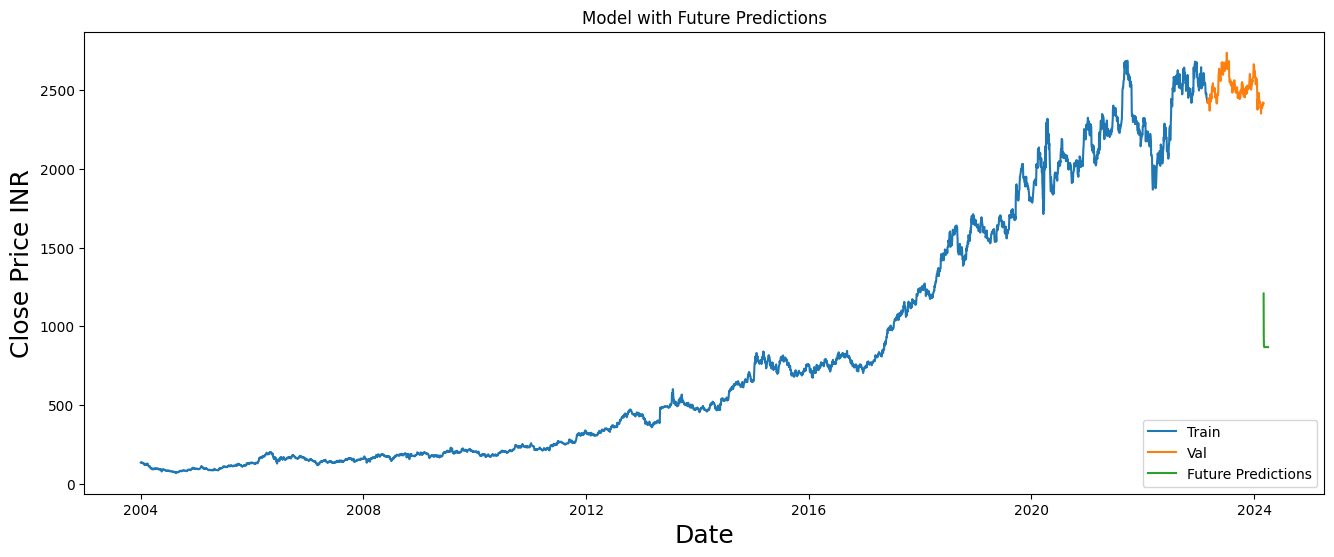

In [19]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Downloading stock data from Yahoo Finance
yf.pdr_override()  # Overriding pandas datareader with yfinance

# Get the stock quote for Hindustan Unilever Limited (HUL)
start_date = '2004-01-01'
end_date = '2024-03-03'

# Retrieving stock data from Yahoo Finance
df = yf.download('HINDUNILVR.NS', start=start_date, end=end_date)

plt.figure(figsize=(16, 6))
plt.title('Close Price History')
plt.plot(df['Adj Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR', fontsize=18)
plt.show()

# Create a new dataframe with only the 'Close' column
data = df.filter(['Adj Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil(len(dataset) * .95))

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i - 60:i, 0])
    y_train.append(train_data[i, 0])

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60:, :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i - 60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print("Root Mean Squared Error:", rmse)

# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]

# Extend prediction for the next 30 days
future_predictions = []
last_sequence = np.copy(test_data[-1])

for _ in range(30):
    # Reshape the last_sequence to match the model input shape
    current_sequence = np.reshape(last_sequence, (1, last_sequence.shape[0], 1))
    # Get the prediction for the next day
    next_pred = model.predict(current_sequence)
    # Inverse transform the prediction and append it to future_predictions
    future_predictions.append(scaler.inverse_transform(next_pred)[0][0])
    # Update last_sequence to include the new prediction and drop the first value
    last_sequence = np.append(last_sequence[1:], next_pred)

# Create a new index for the future predictions
index = pd.date_range(start=df.index[-1], periods=31, closed='right')
# Convert the future predictions to a pandas series with the new index
future_predictions = pd.Series(future_predictions, index=index)

# Visualize the data including future predictions
plt.figure(figsize=(16, 6))
plt.title('Model with Future Predictions')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price INR', fontsize=18)
plt.plot(train['Adj Close'])
plt.plot(valid[['Adj Close']])
plt.plot(future_predictions, label='Future Predictions')
plt.legend(['Train', 'Val', 'Future Predictions'], loc='lower right')
plt.show()


In [20]:
valid

,Adj Close
Date,
2023-02-28,2422.945312
2023-03-01,2428.459717
2023-03-02,2417.726807
2023-03-03,2433.136719
2023-03-06,2446.774658
...,...
2024-02-27,2405.300049
2024-02-28,2421.550049
2024-02-29,2412.300049
